# Machine Learning 2 - Neural Networks

In this lab, we will use simple Neural Networks to classify the images from the simplified CIFAR-10 dataset. We will compare our results with those obtained with Decision Trees and Random Forests.

Lab objectives
----
* Classification with neural networks
* Influence of hidden layers and of the selected features on the classifier results

In [16]:
from lab_tools import CIFAR10, evaluate_classifier, get_hog_image
        
dataset = CIFAR10('/Users/alice/Desktop/INFO-H501 - Pattern/CIFAR10')

import sklearn
print(f"scikit-learn version: {sklearn.__version__}")
print(f"Training set size: {len(dataset.train['hog'])}")
print(f"Test set size:     {len(dataset.test['hog'])}")

Pre-loading training data
Pre-loading test data
scikit-learn version: 1.5.1
Training set size: 15000
Test set size:     3000


We will use the *[Multi-Layer Perceptron](http://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier)* implementation from scikit-learn, which is only available since version 0.18. You can check which version of scikit-learn is installed by executing this :

If you have version 0.17 or older, please update your scikit-learn installation (for instance, with the command *pip install scikit-learn==0.19.1* in the terminal or Anaconda prompt)

1. Data preprocessing

NN are sensitive to feature scales -> use of gradient based optimization so features with diff magnitudes can lead to slow or unstable training.

Standardization of the HoG features to zero mean and unit variance. Scaler is fit only on training set (!data leakage)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(dataset.train['hog'])
X_test  = scaler.transform(dataset.test['hog'])      # use training mean/std on test
y_train = dataset.train['labels']
y_test  = dataset.test['labels']

print("Before scaling - Mean: {:.4f}, Std: {:.4f}".format(
    dataset.train['hog'].mean(), dataset.train['hog'].std()))
print("After scaling  - Mean: {:.4f}, Std: {:.4f}".format(
    X_train.mean(), X_train.std()))

Before scaling - Mean: 0.0039, Std: 0.0057
After scaling  - Mean: -0.0000, Std: 1.0000


## Build a simple neural network

* Using the [MLPClassifier](http://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html) from scikit-learn, create a neural network with a single hidden layer.
* Train this network on the CIFAR dataset.
* Using cross-validation, try to find the best possible parameters.

Descriptive performance

Descriptive accuracy (training set): 0.9428


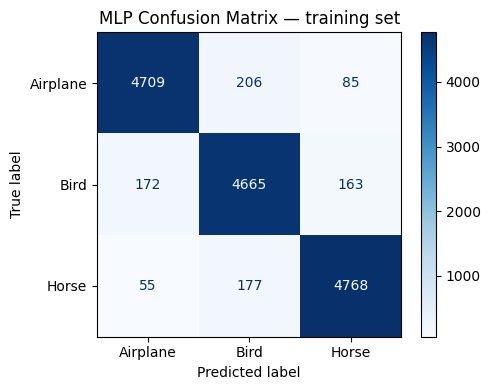

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt 

mlp_clf = MLPClassifier(
    hidden_layer_sizes=(120,),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate='adaptive',
    batch_size='auto',
    early_stopping=True)



# Descriptive performance
mlp_clf.fit(X_train, y_train)
train_acc = mlp_clf.score(X_train, y_train)
print(f"Descriptive accuracy (training set): {train_acc:.4f}")


# Confusion matrix
cm_train = confusion_matrix(y_train, mlp_clf.predict(X_train))
fig, ax = plt.subplots(figsize=(5,4))
disp = ConfusionMatrixDisplay(cm_train, display_labels=dataset.labels)
disp.plot(ax=ax, cmap='Blues')
plt.title('MLP Confusion Matrix — training set')
plt.tight_layout()
plt.savefig('mlp_simple_cm_train.png', dpi=150)
plt.show()



Predictive performance

CV accuracy (5-fold): 0.7980 +- 0.0068
Test set accuracy: 0.8017

Classification report (test set):
              precision    recall  f1-score   support

    Airplane       0.83      0.82      0.83      1000
        Bird       0.74      0.76      0.75      1000
       Horse       0.84      0.82      0.83      1000

    accuracy                           0.80      3000
   macro avg       0.80      0.80      0.80      3000
weighted avg       0.80      0.80      0.80      3000



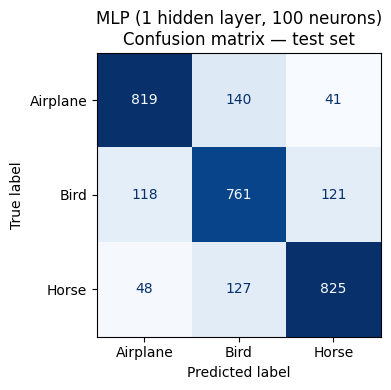

In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_simple = cross_val_score(mlp_clf, X_train, y_train, cv=cv)
print(f"CV accuracy (5-fold): {scores_simple.mean():.4f} +- {scores_simple.std():.4f}")

test_acc = mlp_clf.score(X_test, y_test)
print(f"Test set accuracy: {test_acc:.4f}")

print("\nClassification report (test set):")
print(classification_report(y_test, mlp_clf.predict(X_test), target_names=dataset.labels))

cm_test = confusion_matrix(y_test, mlp_clf.predict(X_test))
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(cm_test, display_labels=dataset.labels)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('MLP (1 hidden layer, 100 neurons)\nConfusion matrix — test set')
plt.tight_layout()
plt.savefig('mlp_simple_cm_test.png', dpi=150)
plt.show()

Hyper parameter tuning

  activation=relu, neurons= 25: 0.7445 +/- 0.0046
  activation=relu, neurons= 50: 0.7759 +/- 0.0064
  activation=relu, neurons=100: 0.7925 +/- 0.0056
  activation=relu, neurons=150: 0.8033 +/- 0.0046
  activation=relu, neurons=200: 0.8091 +/- 0.0043
  activation=relu, neurons=300: 0.8104 +/- 0.0053
  activation=relu, neurons=400: 0.8128 +/- 0.0069
  activation=tanh, neurons= 25: 0.7046 +/- 0.0030
  activation=tanh, neurons= 50: 0.7345 +/- 0.0117
  activation=tanh, neurons=100: 0.7585 +/- 0.0088
  activation=tanh, neurons=150: 0.7701 +/- 0.0046
  activation=tanh, neurons=200: 0.7798 +/- 0.0082
  activation=tanh, neurons=300: 0.7910 +/- 0.0064
  activation=tanh, neurons=400: 0.7929 +/- 0.0106


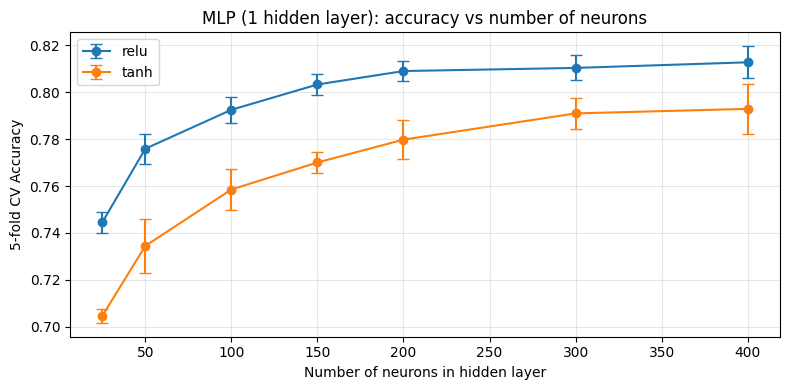

In [30]:
neuron_counts = [25, 50, 100, 150, 200, 300, 400]
results = {}

for activation in ['relu', 'tanh']:
    means, stds = [], []
    for n in neuron_counts:
        clf = MLPClassifier(hidden_layer_sizes=(n,), activation=activation,
                            max_iter=500, random_state=42)
        scores = cross_val_score(clf, X_train, y_train, cv=cv)
        means.append(scores.mean())
        stds.append(scores.std())
        print(f"  activation={activation}, neurons={n:3d}: {scores.mean():.4f} +/- {scores.std():.4f}")
    results[activation] = (means, stds)

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
for activation, (means, stds) in results.items():
    ax.errorbar(neuron_counts, means, yerr=stds, fmt='-o', capsize=4, label=activation)
ax.set_xlabel('Number of neurons in hidden layer')
ax.set_ylabel('5-fold CV Accuracy')
ax.set_title('MLP (1 hidden layer): accuracy vs number of neurons')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mlp_neurons_sweep.png', dpi=150)
plt.show()

## Add hidden layers to the network.

Try to change the structure of the network by adding hidden layers. Using cross-validation, try to find the best architecture for your network.

Architecture                    CV Mean   CV Std
--------------------------------------------------
1 layer (100)                    0.7925   0.0056
2 layers (100, 50)               0.7832   0.0046
2 layers (200, 100)              0.7933   0.0112
3 layers (200,100,50)            0.7953   0.0081
3 layers (100,100,100)           0.7763   0.0104
1 layer (300)                    0.8104   0.0053


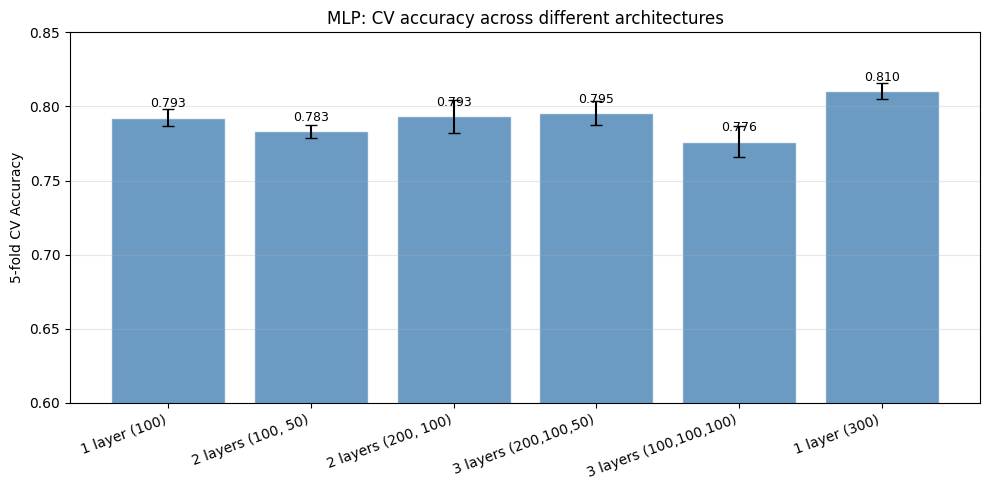

In [25]:
architectures = {
    '1 layer (100)':       (100,),
    '2 layers (100, 50)':  (100, 50), # 2 hidden layers with 100 and 50 neurons
    '2 layers (200, 100)': (200, 100),
    '3 layers (200,100,50)': (200, 100, 50),
    '3 layers (100,100,100)': (100, 100, 100),
    '1 layer (300)':       (300,),
}

arch_scores = {}
print(f"{'Architecture':<30} {'CV Mean':>8} {'CV Std':>8}")
print("-" * 50)

for name, layers in architectures.items():
    clf = MLPClassifier(hidden_layer_sizes=layers, activation='relu',
                        max_iter=500, random_state=42)
    scores = cross_val_score(clf, X_train, y_train, cv=cv)
    arch_scores[name] = scores
    print(f"{name:<30} {scores.mean():>8.4f} {scores.std():>8.4f}")

names  = list(arch_scores.keys())
means  = [arch_scores[n].mean() for n in names]
stds   = [arch_scores[n].std()  for n in names]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(names)), means, yerr=stds, capsize=4,
              color='steelblue', alpha=0.8, edgecolor='white')
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=20, ha='right')
ax.set_ylabel('5-fold CV Accuracy')
ax.set_title('MLP: CV accuracy across different architectures')
ax.set_ylim(0.6, 0.85)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, mean + 0.005,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('mlp_architectures.png', dpi=150)
plt.show()

Grid search

In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'hidden_layer_sizes': [(100,), (200,), (100, 50), (200, 100), (200, 100, 50)],
    'activation':         ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
}

mlp_base = MLPClassifier(max_iter=500, random_state=42)
grid_search = GridSearchCV(mlp_base, param_grid, cv=cv, scoring='accuracy',
                           n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"\nBest parameters:       {grid_search.best_params_}")
print(f"Best CV accuracy:      {grid_search.best_score_:.4f}")
print(f"Test set accuracy:     {grid_search.best_estimator_.score(X_test, y_test):.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters:       {'activation': 'relu', 'hidden_layer_sizes': (200,), 'learning_rate_init': 0.001}
Best CV accuracy:      0.8091
Test set accuracy:     0.8200


Classification report (test set — best MLP):
              precision    recall  f1-score   support

    Airplane       0.85      0.84      0.84      1000
        Bird       0.77      0.78      0.77      1000
       Horse       0.84      0.84      0.84      1000

    accuracy                           0.82      3000
   macro avg       0.82      0.82      0.82      3000
weighted avg       0.82      0.82      0.82      3000



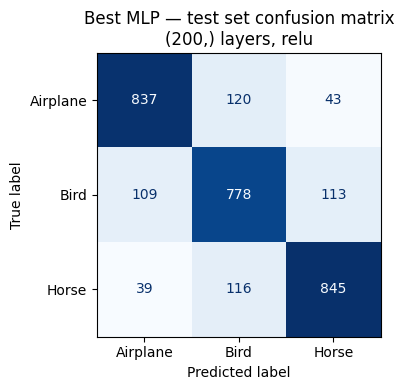

In [28]:
# Evaluate best model fully
best_mlp = grid_search.best_estimator_

print("Classification report (test set — best MLP):")
print(classification_report(y_test, best_mlp.predict(X_test), target_names=dataset.labels))

# Confusion matrix
cm_best = confusion_matrix(y_test, best_mlp.predict(X_test))
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(cm_best, display_labels=dataset.labels)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Best MLP — test set confusion matrix\n{grid_search.best_params_["hidden_layer_sizes"]} layers, {grid_search.best_params_["activation"]}')
plt.tight_layout()
plt.savefig('mlp_best_cm_test.png', dpi=150)
plt.show()

Loss curve 

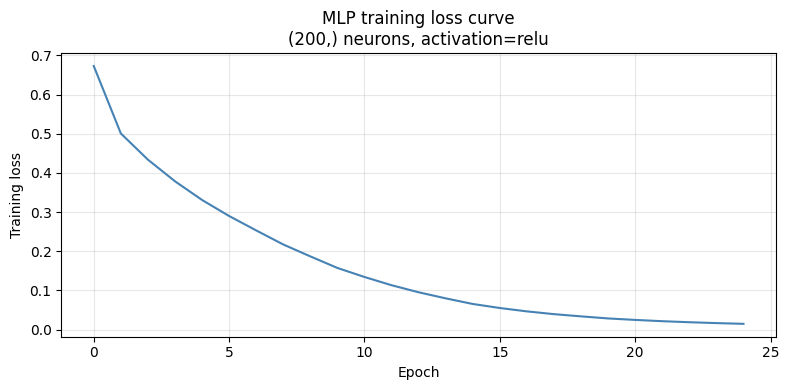

Converged in 25 iterations


In [39]:
best_params = grid_search.best_params_
mlp_for_curve = MLPClassifier(
    hidden_layer_sizes=best_params['hidden_layer_sizes'],
    activation=best_params['activation'],
    learning_rate_init=best_params['learning_rate_init'],
    max_iter=500,
    random_state=42,
    early_stopping =True
)
mlp_for_curve.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlp_for_curve.loss_curve_, color='steelblue', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training loss')
ax.set_title(f'MLP training loss curve\n{best_params["hidden_layer_sizes"]} neurons, activation={best_params["activation"]}')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mlp_loss_curve.png', dpi=150)
plt.show()
print(f"Converged in {mlp_for_curve.n_iter_} iterations")

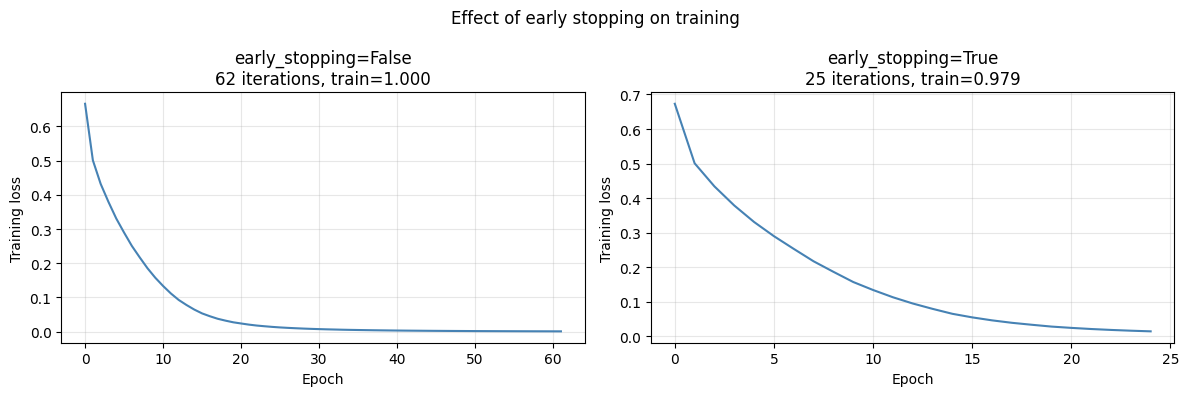

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, early in zip(axes, [False, True]):
    mlp = MLPClassifier(
        hidden_layer_sizes=(200,), activation='relu',
        learning_rate_init=0.001, max_iter=500,
        early_stopping=early, random_state=42
    )
    mlp.fit(X_train, y_train)
    ax.plot(mlp.loss_curve_, color='steelblue', linewidth=1.5)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Training loss')
    title = f'early_stopping={early}\n{mlp.n_iter_} iterations, train={mlp.score(X_train, y_train):.3f}'
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.suptitle('Effect of early stopping on training', fontsize=12)
plt.tight_layout()
plt.savefig('mlp_early_stopping.png', dpi=150)
plt.show()

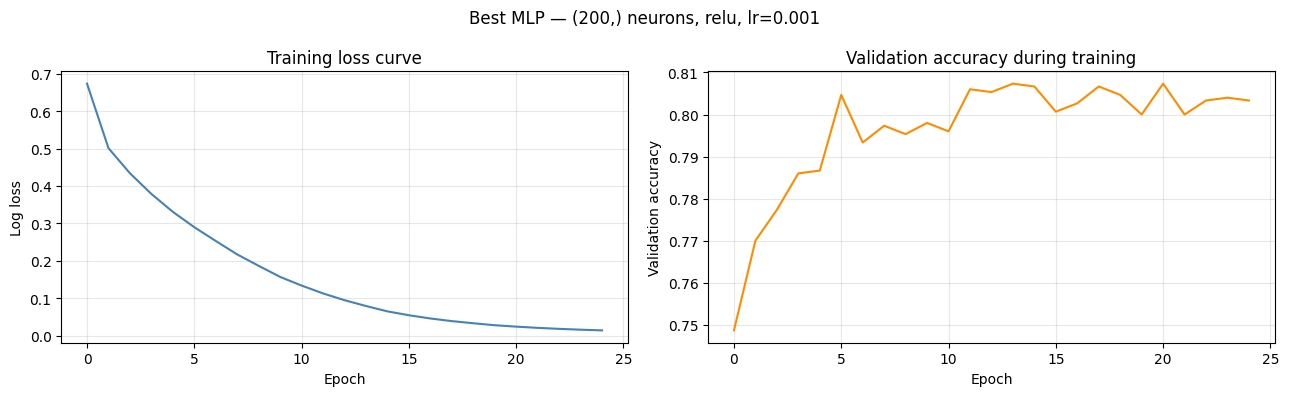

Batch size: auto (200 default) → 75 batches per epoch
Epochs trained: 25
Best validation score reached: 0.8073


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss curve
axes[0].plot(mlp_for_curve.loss_curve_, color='steelblue', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Log loss')
axes[0].set_title('Training loss curve')
axes[0].grid(True, alpha=0.3)

# Validation accuracy curve
axes[1].plot(mlp_for_curve.validation_scores_, color='darkorange', linewidth=1.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation accuracy')
axes[1].set_title('Validation accuracy during training')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Best MLP — (200,) neurons, relu, lr=0.001', fontsize=12)
plt.tight_layout()
plt.savefig('mlp_loss_and_val.png', dpi=150)
plt.show()

# Batch info
print(f"Batch size: auto (200 default) → {len(X_train)/200:.0f} batches per epoch")
print(f"Epochs trained: {mlp_for_curve.n_iter_}")
print(f"Best validation score reached: {max(mlp_for_curve.validation_scores_):.4f}")

1 layer (128)                  CV=0.7980  Test=0.8083
2 layers (128,64)              CV=0.7918  Test=0.7893
3 layers (128,64,32)           CV=0.7863  Test=0.7850
4 layers (128,64,32,16)        CV=0.7857  Test=0.7970


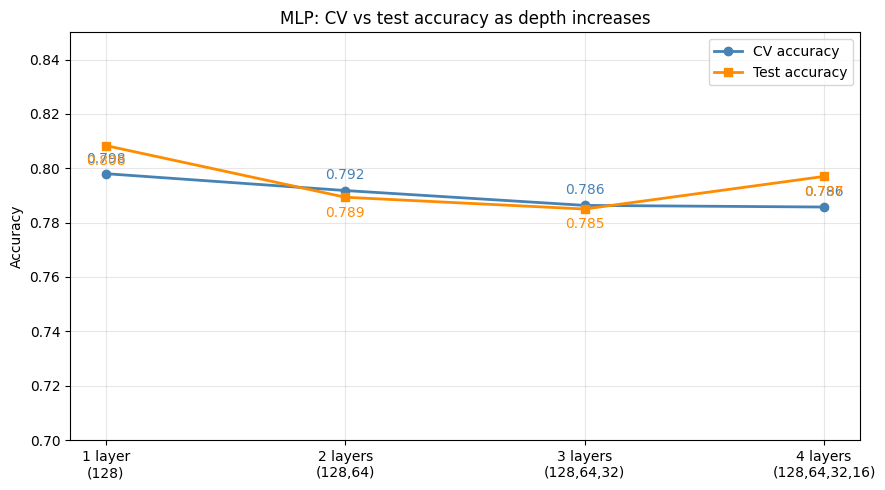

In [33]:
architectures_ordered = {
    '1 layer\n(128)':         (128,),
    '2 layers\n(128,64)':     (128, 64),
    '3 layers\n(128,64,32)':  (128, 64, 32),
    '4 layers\n(128,64,32,16)': (128, 64, 32, 16),
}

cv_accs, test_accs = [], []
for name, layers in architectures_ordered.items():
    clf = MLPClassifier(hidden_layer_sizes=layers, activation='relu',
                        solver='adam', alpha=0.0001, learning_rate='adaptive',
                        early_stopping=True, random_state=42, max_iter=500)
    scores = cross_val_score(clf, X_train, y_train, cv=cv)
    clf.fit(X_train, y_train)
    cv_accs.append(scores.mean())
    test_accs.append(clf.score(X_test, y_test))
    print(f"{name.replace(chr(10),' '):<30} CV={scores.mean():.4f}  Test={clf.score(X_test, y_test):.4f}")

labels = list(architectures_ordered.keys())
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(labels, cv_accs,   '-o', color='steelblue',  label='CV accuracy',   linewidth=2)
ax.plot(labels, test_accs, '-s', color='darkorange',  label='Test accuracy', linewidth=2)
for i, (cv, te) in enumerate(zip(cv_accs, test_accs)):
    ax.annotate(f'{cv:.3f}', (i, cv),   textcoords="offset points", xytext=(0,8),  ha='center', color='steelblue')
    ax.annotate(f'{te:.3f}', (i, te),   textcoords="offset points", xytext=(0,-14), ha='center', color='darkorange')
ax.set_ylabel('Accuracy')
ax.set_title('MLP: CV vs test accuracy as depth increases')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0.70, 0.85)
plt.tight_layout()
plt.savefig('mlp_depth_comparison.png', dpi=150)
plt.show()

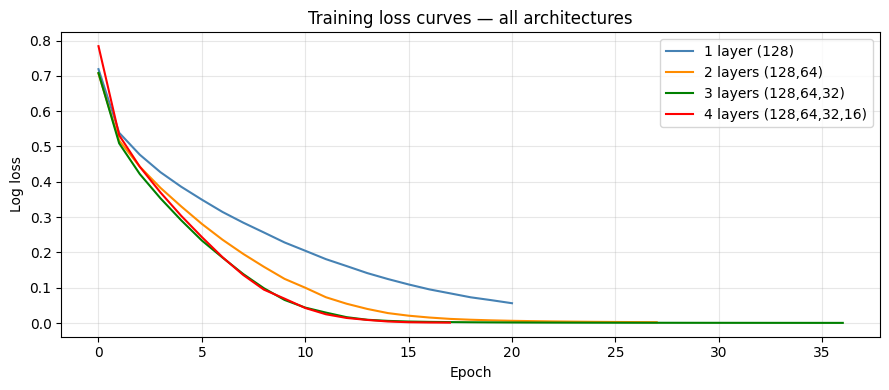

In [34]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['steelblue', 'darkorange', 'green', 'red']
fitted_clfs = []

for (name, layers), color in zip(architectures_ordered.items(), colors):
    clf = MLPClassifier(hidden_layer_sizes=layers, activation='relu',
                        solver='adam', alpha=0.0001, learning_rate='adaptive',
                        early_stopping=True, random_state=42, max_iter=500)
    clf.fit(X_train, y_train)
    ax.plot(clf.loss_curve_, color=color, linewidth=1.5, label=name.replace('\n', ' '))
    fitted_clfs.append(clf)

ax.set_xlabel('Epoch')
ax.set_ylabel('Log loss')
ax.set_title('Training loss curves — all architectures')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mlp_loss_curves_all.png', dpi=150)
plt.show()

In [42]:
# Direct comparison: scaled vs unscaled, same architecture
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

arch = (128, 64, 32)  # classmate's best

clf_raw    = MLPClassifier(hidden_layer_sizes=arch, activation='relu', solver='adam',
                           alpha=0.0001, learning_rate='adaptive',
                           early_stopping=True, random_state=42, max_iter=500)
clf_scaled = MLPClassifier(hidden_layer_sizes=arch, activation='relu', solver='adam',
                           alpha=0.0001, learning_rate='adaptive',
                           early_stopping=True, random_state=42, max_iter=500)

scores_raw    = cross_val_score(clf_raw,    dataset.train['hog'], y_train, cv=cv)
scores_scaled = cross_val_score(clf_scaled, X_train,              y_train, cv=cv)

clf_raw.fit(dataset.train['hog'], y_train)
clf_scaled.fit(X_train, y_train)

print(f"Same architecture (128, 64, 32) — effect of standardization:")
print(f"  Raw HoG:    CV={scores_raw.mean():.4f}    Test={clf_raw.score(dataset.test['hog'], y_test):.4f}")
print(f"  Scaled HoG: CV={scores_scaled.mean():.4f}    Test={clf_scaled.score(X_test, y_test):.4f}")

Same architecture (128, 64, 32) — effect of standardization:
  Raw HoG:    CV=0.7821    Test=0.7877
  Scaled HoG: CV=0.7863    Test=0.7850
